### <font color='#BFD72F'>Table of Contents </font> <a class="anchor" id='toc'></a> 
- [0. Imports](#P0)
- [1. Text Cleaning](#P1)
- [2. Text Normalization](#P2)
- [3. Tokenization](#P3)
- [4. Stopword removal](#P4)
- [5. Lemmatization](#P5)
- [6. Stemming](#P6)
- [7. POS Tagging](#P7)

<font color='#BFD72F' size=5>0. Imports</font> <a class="anchor" id="P0"></a>
  
[Back to TOC](#toc)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from collections import Counter

In [2]:
df = pd.read_csv("EUPDCorp_agenda_fixed.csv")

In [3]:
# Keep only the specified columns
df = df[["date", "doc_id", "speech_en", "party_name"]].copy()
df.head()

,date,doc_id,speech_en,party_name
0,1999-07-20,1.0,I declare resumed the session adjourned on 7 M...,Democratici di Sinistra
1,1999-07-20,2.0,"Mr President, I should like to thank you for g...",Fianna Fáil Party
2,1999-07-20,3.0,"Mr. Crowley, your protest will certainly be no...",Democratici di Sinistra
3,1999-07-20,4.0,"I have to inform you that, pursuant to Rule 12...",Democratici di Sinistra
4,1999-07-20,5.0,"Mr President, I would like to ask for the floo...",Lista Emma Bonino


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563696 entries, 0 to 563695
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        563696 non-null  object 
 1   doc_id      563696 non-null  float64
 2   speech_en   563696 non-null  object 
 3   party_name  563672 non-null  object 
dtypes: float64(1), object(3)
memory usage: 17.2+ MB


In [5]:
df.columns

Index(['date', 'doc_id', 'speech_en', 'party_name'], dtype='object')

<font color='#BFD72F' size=5>1. Text Cleaning</font> <a class="anchor" id="P1"></a>

- Handle missing values
- Remove HTML tags
- Remove URLs
- Remove email addresses
- Remove punctuation, emojis, and special characters
- Remove underscores
- Normalize whitespace
- Convert to lowercase
- Tokenize

[Back to TOC](#toc)

In [6]:

import pandas as pd
import re
from tqdm.auto import tqdm


def clean_text_column(df: pd.DataFrame, text_column: str) -> pd.DataFrame:
    """
    Clean and tokenize a text column by converting to lowercase,
    removing URLs, email addresses, HTML tags, punctuation,
    special characters, and extra whitespace.

    Returns a copy of the DataFrame with tokenized text.
    """

    # Create a copy to avoid modifying the original DataFrame
    df = df.copy()

    # Enable progress_apply() for pandas
    tqdm.pandas(desc="Cleaning and tokenizing text")

    def clean_text(text):

        # Handle missing values
        if pd.isna(text):
            return []

        # Convert the text to a string
        text = str(text)

        # Convert all text to lowercase
        text = text.lower()

        # Remove HTML tags
        text = re.sub(r"<[^>]+>", " ", text)

        # Remove URLs
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)

        # Remove email addresses
        text = re.sub(
            r"\b[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}\b",
            " ",
            text
        )

        # Remove punctuation, emojis, and special characters
        # Keep letters, digits, and whitespace
        text = re.sub(r"[^\w\s]", " ", text)

        # Remove underscores
        text = re.sub(r"_+", " ", text)

        # Normalize whitespace
        text = re.sub(r"\s+", " ", text).strip()

        # Tokenization: split the cleaned text into individual words
        tokens = text.split()

        return tokens

    # Apply cleaning and tokenization with a progress bar
    df[text_column] = df[text_column].progress_apply(clean_text)

    return df

c:\Users\Rafael\Documents\GitHub\Dissertacao_UE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
df = clean_text_column(df, "speech_en")
df

Cleaning and tokenizing text: 100%|██████████| 563696/563696 [00:43<00:00, 13057.41it/s]


,date,doc_id,speech_en,party_name
0,1999-07-20,1.0,"[i, declare, resumed, the, session, adjourned,...",Democratici di Sinistra
1,1999-07-20,2.0,"[mr, president, i, should, like, to, thank, yo...",Fianna Fáil Party
2,1999-07-20,3.0,"[mr, crowley, your, protest, will, certainly, ...",Democratici di Sinistra
3,1999-07-20,4.0,"[i, have, to, inform, you, that, pursuant, to,...",Democratici di Sinistra
4,1999-07-20,5.0,"[mr, president, i, would, like, to, ask, for, ...",Lista Emma Bonino
...,...,...,...,...
563691,2024-02-08,563842.0,"[mr, president, do, i, think, that, there, s, ...",Independents for change
563692,2024-02-08,563843.0,"[they, ve, finished, the, oral, ballot, statem...",NaN
563693,2024-02-08,563844.0,"[the, minutes, of, this, sitting, will, be, su...",NaN
563694,2024-02-08,563845.0,"[the, next, session, will, take, place, from, ...",NaN


<font color='#BFD72F' size=5>2. Text Normalization</font> <a class="anchor" id="P2"></a>


[Back to TOC](#toc)

<font color='crimson' size=4>TODO: Date or Text normalization</font> 


<font color='#BFD72F' size=5>3. Stopword removal</font> <a class="anchor" id="P3"></a>



[Back to TOC](#toc)

In [8]:

import pandas as pd
from collections import Counter
from nltk.corpus import stopwords
from nltk import download


# Download the English stopwords corpus if necessary.
download("stopwords", quiet=True)

# Load the standard English stopwords.
stop_words = set(stopwords.words("english"))


def remove_stopwords(
    df: pd.DataFrame,
    text_column: str
) -> pd.DataFrame:
    """
    Remove common English stopwords from a tokenized text column.

    The input column must contain lists of tokens.
    Returns a copy of the DataFrame with a new column.
    """

    # Preserve the original DataFrame.
    df = df.copy()

    def filter_stopwords(tokens):
        # Handle missing values.
        if not isinstance(tokens, list):
            return []

        # Keep tokens that are not common English stopwords.
        return [
            token for token in tokens
            if token.lower() not in stop_words
        ]

    # Create a separate column to preserve the original tokens.
    df["tokens_no_stopwords"] = df[text_column].apply(
        filter_stopwords
    )

    return df


def get_top_words(
    df: pd.DataFrame,
    text_column: str = "tokens_no_stopwords",
    n: int = 100
) -> pd.DataFrame:
    """
    Return the n most frequent words across all documents.
    """

    # Combine the tokens from all rows and count their occurrences.
    word_counts = Counter(
        token
        for tokens in df[text_column]
        for token in tokens
    )

    # Return the most frequent words as a DataFrame.
    top_words = pd.DataFrame(
        word_counts.most_common(n),
        columns=["word", "frequency"]
    )

    return top_words


# --------------------------------------------------
# Run the analysis
# --------------------------------------------------

# Replace "tokens" with the name of your current token column.
df_processed = remove_stopwords(
    df,
    text_column="speech_en"
)

# Get the 100 most common words after stopword removal.
top_100_words = get_top_words(
    df_processed,
    text_column="tokens_no_stopwords",
    n=100
)

# Display all 100 words and their frequencies.
print(top_100_words.to_string(index=False))

         word  frequency
     european     813266
   commission     422359
         also     412415
        union     386348
        would     315818
           eu     309939
       report     288410
       states     286997
       member     284475
         must     284308
    president     283094
           mr     282935
   parliament     261211
      writing     246175
       europe     216523
      council     209928
         like     207599
    countries     183675
       people     182703
          one     175627
          new     171785
      support     169796
    important     168933
         need     167555
       rights     166859
    therefore     154844
       policy     147290
           us     146848
     economic     135372
        voted     132746
         work     132507
         time     131500
     citizens     126164
       favour     124545
       market     122313
    agreement     120925
        think     120143
    financial     120005
       social     119521


In [9]:

import plotly.express as px


import sys
import nbformat

print("Python interpreter:", sys.executable)
print("nbformat version:", nbformat.__version__)
print("nbformat location:", nbformat.__file__)

# Select the top 30 most frequent words.
top_n_words = top_100_words.head(30).sort_values(
    by="frequency",
    ascending=True
)

# Create an interactive horizontal bar chart.
fig = px.bar(
    top_n_words,
    x="frequency",
    y="word",
    orientation="h",
    title="Top 30 Most Frequent Words After Stopword Removal",
    labels={
        "frequency": "Frequency",
        "word": "Word"
    },
    hover_data={"frequency": ":,"}
)

# Improve the chart layout.
fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Frequency",
    yaxis_title="Word",
    height=800
)

# Display the chart.
fig.show()

Python interpreter: c:\Users\Rafael\Documents\GitHub\Dissertacao_UE\.venv\Scripts\python.exe
nbformat version: 5.11.1
nbformat location: c:\Users\Rafael\Documents\GitHub\Dissertacao_UE\.venv\Lib\site-packages\nbformat\__init__.py


---------------

In [11]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    tokens = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["speech_no_stopwords"] = df["speech_en"].apply(remove_stopwords)

df[["speech_en", "speech_no_stopwords"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,speech_en,speech_no_stopwords
0,I declare resumed the session adjourned on 7 M...,declare resumed session adjourned may open sit...
1,"Mr President, I should like to thank you for g...",mr president like thank giving opportunity add...
2,"Mr. Crowley, your protest will certainly be no...",mr crowley protest certainly noted wish expres...
3,"I have to inform you that, pursuant to Rule 12...",inform pursuant rule rules procedure duties de...
4,"Mr President, I would like to ask for the floo...",mr president would like ask floor refer rules ...


In [17]:
all_words = " ".join(df["speech_no_stopwords"])

word_counts = Counter(all_words.split())

most_common = pd.DataFrame(
    word_counts.most_common(30),
    columns=["word", "frequency"]
)

most_common

,word,frequency
0,european,813266
1,commission,422359
2,also,412415
3,union,386348
4,would,315818
5,eu,309986
6,report,288410
7,states,286998
8,member,284476
9,must,284300


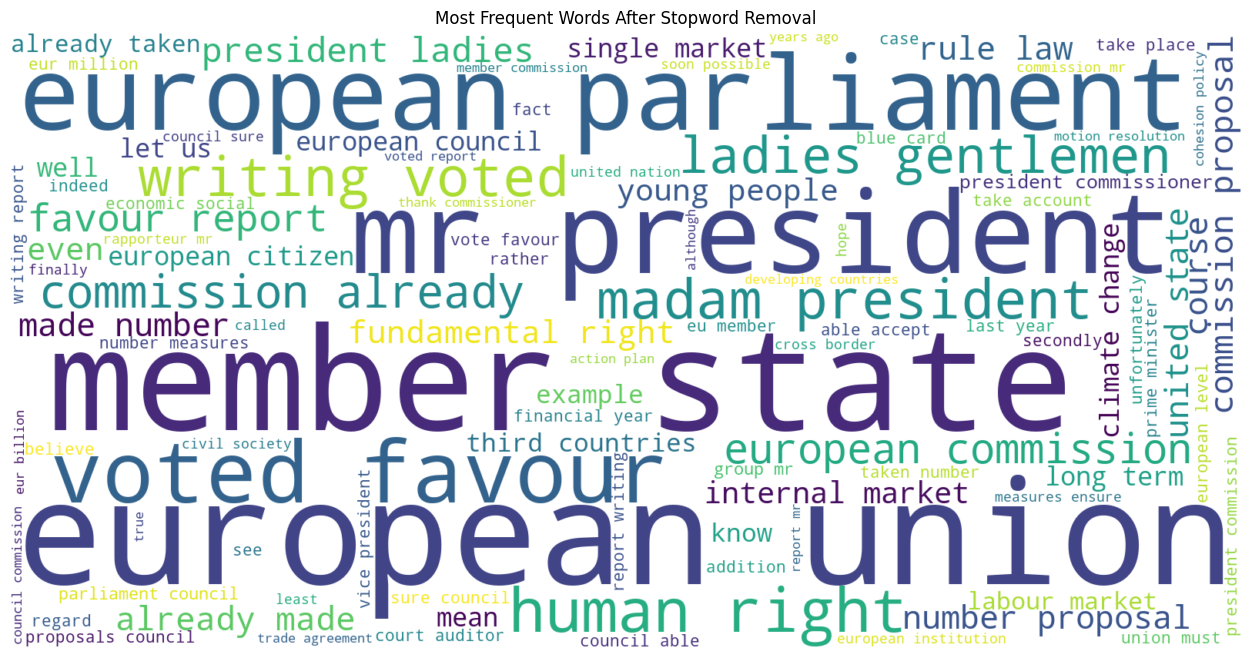

In [ ]:
# Criar WordCloud
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=100
).generate(all_words)

# Mostrar
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words After Stopword Removal")
plt.show()

In [22]:
custom_stopwords = {
    "european",
    "commission",
    "also",
    "union",
    "would",
    "eu",
    "report",
    "states",
    "member",
    "president",
    "mr",
    "parliament",
    "europe",
    "council",
    "like",
    "countries",
    "therefore",
    "ladies",
    "gentleman",
    "prime",
    "minister"
}

In [23]:
all_stopwords = stop_words.union(custom_stopwords)

def remove_stopwords_custom(text):
    tokens = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())
    tokens = [word for word in tokens if word not in all_stopwords]
    return " ".join(tokens)

df["speech_no_custom_stopwords"] = df["speech_en"].apply(
    remove_stopwords_custom
)

In [25]:
all_words = " ".join(df["speech_no_custom_stopwords"])

word_counts = Counter(all_words.split())

most_common = pd.DataFrame(
    word_counts.most_common(30),
    columns=["word", "frequency"]
)

most_common

,word,frequency
0,must,284300
1,writing,246175
2,people,182703
3,one,175627
4,new,171785
5,support,169796
6,important,168933
7,need,167555
8,rights,166859
9,policy,147294


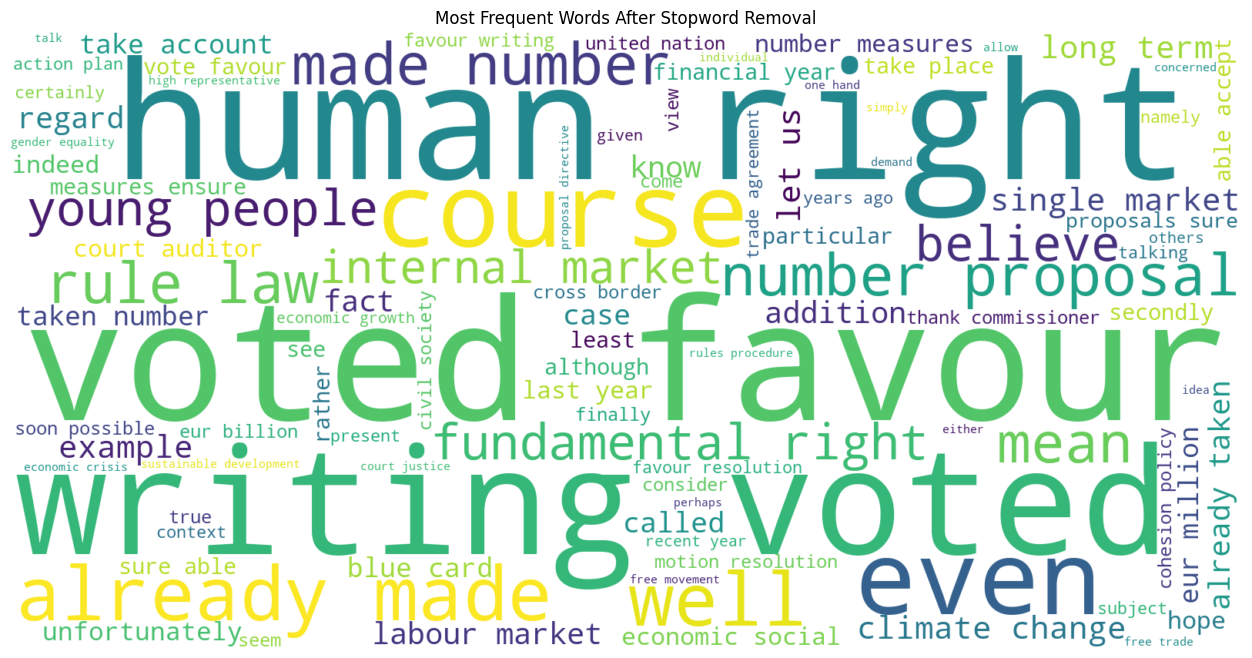

In [24]:
all_words_custom = " ".join(df["speech_no_custom_stopwords"])

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=100
).generate(all_words_custom)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words After Stopword Removal")
plt.show()